In [68]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [69]:
transform = transforms.Compose([
    transforms.Resize(512),
    transforms.CenterCrop(512),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])

In [65]:
class CEDARSignature(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform

    def __len__(self):
        return 55 * 24

    def __getitem__(self, idx):
        sig_number = int(idx // 24) + 1
        sig_copy = int(idx % 24) + 1
        label = random.choice(["original", "forgeries"])
        random_copy = random.choice([i for i in range(1, 24) if i != sig_copy])

        anchor_path = os.path.join(self.root, f"full_org/original_{sig_number}_{sig_copy}.png")

        if label == "original":
            test_path = os.path.join(self.root, f"full_org/original_{sig_number}_{random_copy}.png")
        else:
            test_path = os.path.join(self.root, f"full_forg/forgeries_{sig_number}_{random_copy}.png")

        anchor_img = Image.open(anchor_path).convert("L")
        test_img = Image.open(test_path).convert("L")

        if self.transform:
            anchor_img = self.transform(anchor_img)
            test_img = self.transform(test_img)

        return anchor_img, test_img, label

In [66]:
dataset = CEDARSignature(root="../data/signatures", transform=transform)

train_len = int(0.8 * len(dataset))
test_len = len(dataset) - train_len

train_set, test_set = random_split(dataset, [train_len, test_len])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

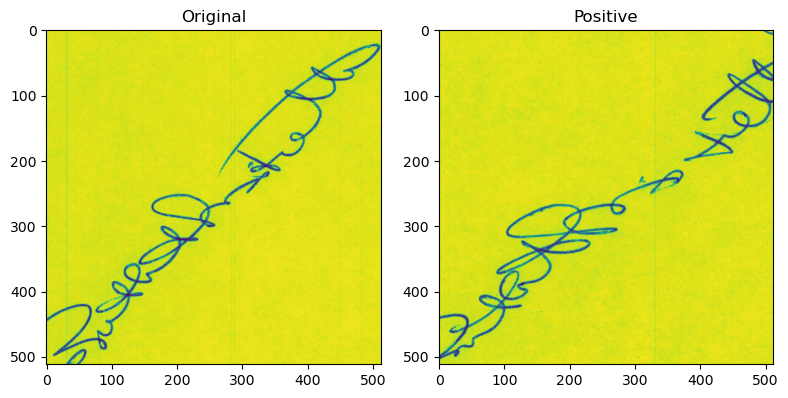

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

mean, std = 0.5, 0.5
anchor, test, label = next(iter(train_loader))
transformed_anchor = torch.squeeze(anchor[0] * std + mean, 0)
transformed_test = torch.squeeze(test[0] * std + mean, 0)

axes[0].imshow(transforms.ToPILImage()(transformed_anchor))
axes[0].set_title("Original")

axes[1].imshow(transforms.ToPILImage()(transformed_test))
axes[1].set_title("Positive" if label[0] == "original" else "Forgeries")

plt.tight_layout()
plt.show()

In [88]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedded_layer = nn.Sequential(
            nn.Conv2d(),
            nn.ReLU(),
            nn.MaxPool2d()
        )

    def forward(self, anchor, test):
        enc1 = self.embedded_layer(anchor)
        enc2 = self.embedded_layer(test)

        return enc1, enc2